In [ ]:
!pip install kagglehub
!pip install torch torchvision pillow scikit-learn tqdm

In [ ]:
import kagglehub
import os


path = kagglehub.dataset_download("robinreni/house-rooms-image-dataset")

print("Dataset path:", path)

print("Folders inside dataset:")
print(os.listdir(path))

100%|██████████| 116M/116M [00:00<00:00, 151MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/robinreni/house-rooms-image-dataset/versions/1
Folders inside dataset:
['House_Room_Dataset']


In [ ]:
import os
import random
import shutil

dataset_path = os.path.join(path, "House_Room_Dataset")
output_dataset_path = "./balanced_dataset"


min_count = float('inf')

for folder_name in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder_name)

    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))
        min_count = min(min_count, num_images)

print("Minimum images per class:", min_count)



if not os.path.exists(output_dataset_path):
    os.makedirs(output_dataset_path)

for folder_name in os.listdir(dataset_path):
    source_folder_path = os.path.join(dataset_path, folder_name)
    destination_folder_path = os.path.join(output_dataset_path, folder_name)

    if os.path.isdir(source_folder_path):
        if not os.path.exists(destination_folder_path):
            os.makedirs(destination_folder_path)

        images = os.listdir(source_folder_path)

        selected_images = random.sample(images, min_count)

        for img_name in selected_images:
            source_img_path = os.path.join(source_folder_path, img_name)
            destination_img_path = os.path.join(destination_folder_path, img_name)
            shutil.copy(source_img_path, destination_img_path)

        print(folder_name, "balanced to", min_count, "images and copied to", destination_folder_path)


dataset_path = output_dataset_path
print(f"Dataset path updated to: {dataset_path}")

Minimum images per class: 606
Bathroom balanced to 606 images and copied to ./balanced_dataset/Bathroom
Dinning balanced to 606 images and copied to ./balanced_dataset/Dinning
Kitchen balanced to 606 images and copied to ./balanced_dataset/Kitchen
Bedroom balanced to 606 images and copied to ./balanced_dataset/Bedroom
Livingroom balanced to 606 images and copied to ./balanced_dataset/Livingroom
Dataset path updated to: ./balanced_dataset


In [ ]:
from PIL import Image
import os

bad_images = []

for room in os.listdir(dataset_path):

    room_path = os.path.join(dataset_path, room)

    if not os.path.isdir(room_path):
        continue

    for img_name in os.listdir(room_path):

        img_path = os.path.join(room_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            bad_images.append(img_path)

print("Corrupted images:", len(bad_images))

for img in bad_images:
    os.remove(img)

print("Removed corrupted images")

Corrupted images: 0
Removed corrupted images


In [ ]:
from PIL import Image
from tqdm import tqdm

TARGET_SIZE = (224,224)

for room in os.listdir(dataset_path):

    room_path = os.path.join(dataset_path, room)

    if not os.path.isdir(room_path):
        continue

    for img_name in tqdm(os.listdir(room_path)):

        img_path = os.path.join(room_path, img_name)

        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize(TARGET_SIZE)
            img.save(img_path)
        except:
            pass

print("All images resized")


100%|██████████| 606/606 [00:01<00:00, 395.74it/s]

All images resized


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

split_root = "/content/dataset_split"

train_dir = os.path.join(split_root, "train")
val_dir = os.path.join(split_root, "val")
test_dir = os.path.join(split_root, "test")

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for room in os.listdir(dataset_path):

    room_path = os.path.join(dataset_path, room)

    if not os.path.isdir(room_path):
        continue

    images = os.listdir(room_path)


    train_imgs, temp_imgs = train_test_split(
        images, test_size=0.30, random_state=42
    )


    val_imgs, test_imgs = train_test_split(
        temp_imgs, test_size=0.5, random_state=42
    )


    for split in ["train", "val", "test"]:
        os.makedirs(os.path.join(split_root, split, room), exist_ok=True)


    for img in train_imgs:
        shutil.copy(
            os.path.join(room_path, img),
            os.path.join(train_dir, room, img)
        )


    for img in val_imgs:
        shutil.copy(
            os.path.join(room_path, img),
            os.path.join(val_dir, room, img)
        )


    for img in test_imgs:
        shutil.copy(
            os.path.join(room_path, img),
            os.path.join(test_dir, room, img)
        )

print("Dataset split completed (70% Train, 15% Val, 15% Test)")

Dataset split completed (70% Train, 15% Val, 15% Test)


In [ ]:
for split in ["train","val","test"]:

    split_path = os.path.join(split_root, split)

    print("\n",split.upper())

    for room in os.listdir(split_path):

        room_path = os.path.join(split_path, room)

        print(room, ":", len(os.listdir(room_path)))


 TRAIN
Bathroom : 424
Dinning : 424
Kitchen : 424
Bedroom : 424
Livingroom : 424

 VAL
Bathroom : 91
Dinning : 91
Kitchen : 91
Bedroom : 91
Livingroom : 91

 TEST
Bathroom : 91
Dinning : 91
Kitchen : 91
Bedroom : 91
Livingroom : 91


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([

    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root="/content/dataset_split/train",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root="/content/dataset_split/val",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root="/content/dataset_split/test",
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Classes:", train_dataset.classes)
print("Training samples:", len(train_dataset))

Classes: ['Bathroom', 'Bedroom', 'Dinning', 'Kitchen', 'Livingroom']
Training samples: 2120


(np.float64(-0.5), np.float64(905.5), np.float64(453.5), np.float64(-0.5))

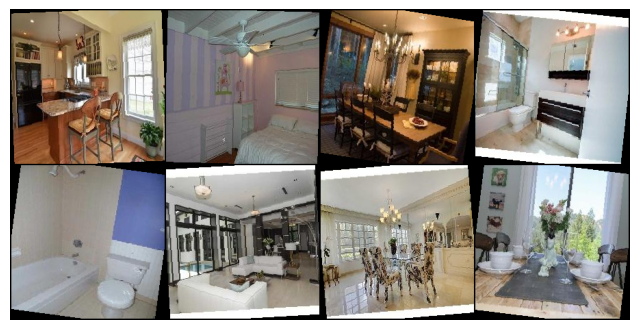

In [ ]:
import matplotlib.pyplot as plt
import torchvision

images, labels = next(iter(train_loader))

grid = torchvision.utils.make_grid(images[:8], nrow=4)

plt.figure(figsize=(8,6))
plt.imshow(grid.permute(1,2,0))
plt.axis("off")

In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model = models.resnet50(pretrained=True)


num_classes = len(train_dataset.classes)


model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

print("Classes:", train_dataset.classes)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 116MB/s]


Classes: ['Bathroom', 'Bedroom', 'Dinning', 'Kitchen', 'Livingroom']


In [ ]:


LEARNING_RATE = 0.0001
WEIGHT_DECAY = 0.0001
EARLY_STOPPING_PATIENCE = 4

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.3
)

In [ ]:
from tqdm import tqdm
import torch
import time

def train_model(model, train_loader, val_loader, epochs=20):

    training_history = []

    for epoch in range(epochs):

        epoch_start = time.time()

        # TRAINING
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader)

        for images, labels in loop:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loop.set_description(f"Epoch {epoch+1}")
            loop.set_postfix(loss=loss.item())

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        #  VALIDATION
        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct / total

        scheduler.step(val_loss)

        epoch_time = (time.time() - epoch_start) * 1000

        metrics = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "epoch_latency_ms": epoch_time
        }

        training_history.append(metrics)

        print(f"\nEpoch {epoch+1}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return training_history

In [ ]:
train_model(model, train_loader, val_loader, epochs=20)

Epoch 1: 100%|██████████| 67/67 [00:25<00:00,  2.64it/s, loss=0.541]



Epoch 1
Train Loss: 0.7268 | Train Acc: 73.30%
Val Loss: 0.5110 | Val Acc: 81.54%


Epoch 2: 100%|██████████| 67/67 [00:23<00:00,  2.88it/s, loss=0.0464]



Epoch 2
Train Loss: 0.2937 | Train Acc: 90.52%
Val Loss: 0.4232 | Val Acc: 85.05%


Epoch 3: 100%|██████████| 67/67 [00:24<00:00,  2.76it/s, loss=0.00953]


...

Epoch 19: 100%|██████████| 67/67 [00:26<00:00,  2.54it/s, loss=0.0106]



Epoch 19
Train Loss: 0.0086 | Train Acc: 99.76%
Val Loss: 0.5290 | Val Acc: 86.37%


Epoch 20: 100%|██████████| 67/67 [00:26<00:00,  2.54it/s, loss=0.0407]



Epoch 20
Train Loss: 0.0114 | Train Acc: 99.76%
Val Loss: 0.4970 | Val Acc: 88.35%


[{'epoch': 1,
  'train_loss': 0.7267663223085119,
  'train_accuracy': 73.30188679245283,
  'val_loss': 0.510958322385947,
  'val_accuracy': 81.53846153846153,
  'epoch_latency_ms': 27312.060594558716},
 {'epoch': 2,
  'train_loss': 0.29370951463482275,
  'train_accuracy': 90.51886792452831,
  'val_loss': 0.4232043574253718,
  'val_accuracy': 85.05494505494505,
  'epoch_latency_ms': 25129.64916229248},
 {'epoch': 3,
  'train_loss': 0.18441771544905297,
  'train_accuracy': 93.82075471698113,
  'val_loss': 0.6287638887763023,
  'val_accuracy': 83.07692307692308,
  'epoch_latency_ms': 26173.978328704834},
 {'epoch': 4,
  'train_loss': 0.13362047458484547,
  'train_accuracy': 95.70754716981132,
  'val_loss': 0.5227243736386299,
  'val_accuracy': 83.51648351648352,
  'epoch_latency_ms': 26461.95912361145},
 {'epoch': 5,
  'train_loss': 0.1314551032829418,
  'train_accuracy': 95.56603773584905,
  'val_loss': 0.6036322594930729,
  'val_accuracy': 83.51648351648352,
  'epoch_latency_ms': 27385.

In [ ]:
import torch
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())


accuracy = accuracy_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.8857
F1 Score: 0.8850
Precision: 0.8873
Recall: 0.8857


In [ ]:
torch.save(model.state_dict(), "asrith-test.pth")

print("Model saved!")

Model saved!


In [ ]:


import torch
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import time
import uuid
import json
import requests
from io import BytesIO


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


ROOM_CLASSES = ['Bathroom', 'Bedroom', 'Dinning', 'Kitchen', 'Livingroom']

MODEL_VERSION = "resnet50_v3_2026-03-14"
UNKNOWN_THRESHOLD = 0.6


model = models.resnet50(weights=None)
model.fc = torch.nn.Linear(model.fc.in_features, 5)

model.load_state_dict(torch.load("/content/asrith-test.pth", map_location=device))
model.to(device)
model.eval()

print("✅ Model Loaded")


transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


def predict_room(model, image_tensor):

    request_id = str(uuid.uuid4())
    start_total = time.time()

    start_cls = time.time()

    with torch.no_grad():
        outputs = model(image_tensor.to(device))
        probs = F.softmax(outputs, dim=1)

    latency_cls = (time.time() - start_cls) * 1000

    confidence, predicted = torch.max(probs, 1)

    room_type = ROOM_CLASSES[predicted.item()]
    confidence = confidence.item()

    top_probs, top_indices = torch.topk(probs, 3)

    top_predictions = [
        {
            "room_type": ROOM_CLASSES[idx.item()],
            "confidence": prob.item()
        }
        for prob, idx in zip(top_probs[0], top_indices[0])
    ]

    is_unknown = confidence < UNKNOWN_THRESHOLD

    latency_total = (time.time() - start_total) * 1000

    response = {
        "request_id": request_id,
        "prediction": {
            "room_type": room_type,
            "confidence": confidence,
            "top_predictions": top_predictions,
            "is_unknown": is_unknown
        },
        "model_info": {
            "model_version": MODEL_VERSION,
            "embedding_model_version": "clip_vit_b32_openai",
            "metadata_provider": "gemini"
        },
        "latency": {
            "latency_ms_total": latency_total,
            "latency_ms_classification": latency_cls
        },
        "thresholds_used": {
            "unknown_threshold": UNKNOWN_THRESHOLD,
            "duplicate_threshold": 0.92
        },
        "input_info": {
            "image_size": list(image_tensor.shape),
            "mime_type": "image/jpeg"
        }
    }


    return response




IMAGE_PATH = "/content/test-dining.jpg"



try:
    image = Image.open(IMAGE_PATH).convert("RGB")
except:
    response = requests.get(IMAGE_URL)
    image = Image.open(BytesIO(response.content)).convert("RGB")

image_tensor = transform(image).unsqueeze(0)

result = predict_room(model, image_tensor)

print(json.dumps(result, indent=2))